In [1]:
import cv2
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt


import warnings
import os
import json
import random
import shutil
from pathlib import Path

from collections import defaultdict
from sklearn.model_selection import train_test_split
warnings.filterwarnings("ignore")

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/ct-adrenal-tumor-dataset
/kaggle/input/ct-adrenal-tumor-dataset/segmentation
/kaggle/input/ct-adrenal-tumor-dataset/segmentation/videos
/kaggle/input/ct-adrenal-tumor-dataset/segmentation/masks
/kaggle/input/ct-adrenal-tumor-dataset/classification
/kaggle/input/ct-adrenal-tumor-dataset/classification/indeterminate
/kaggle/input/ct-adrenal-tumor-dataset/classification/indeterminate/videos
/kaggle/input/ct-adrenal-tumor-dataset/classification/indeterminate/masks
/kaggle/input/ct-adrenal-tumor-dataset/classification/benign
/kaggle/input/ct-adrenal-tumor-dataset/classification/benign/videos
/kaggle/input/ct-adrenal-tumor-dataset/classification/benign/masks
/kaggle/input/ct-adrenal-tumor-dataset/classification/malignant
/kaggle/input/ct-adrenal-tumor-dataset/classification/malignant/videos
/kaggle/input/ct-adrenal-tumor-dataset/classification/malignant/masks


In [2]:
import torch

# Проверка доступности CUDA
if torch.cuda.is_available():
    print("CUDA доступна")
    print("Имя устройства:", torch.cuda.get_device_name(0))
    print("Кол-во устройств:", torch.cuda.device_count())

CUDA доступна
Имя устройства: Tesla T4
Кол-во устройств: 2


In [3]:
# Подключаем датасет
project_dir = '/kaggle/input/ct-adrenal-tumor-dataset/segmentation'

video_dir = project_dir + "/videos"
masks_dir = project_dir + "/masks"

videos_file = video_dir +  '/ID100_ARTERIAL.npy'
masks_file = masks_dir + '/ID100_ARTERIAL_MASK.npy'

try:
    videos = np.load(videos_file)
    print("Файл 'videos' загружен успешно.")
except FileNotFoundError:
    print("Файл 'videos' не найден. Проверьте правильность пути.")

Файл 'videos' загружен успешно.


In [4]:
# Загрузка массивов
videos = np.load(videos_file)
masks = np.load(masks_file)

print(f"Размерность массива видео: {videos.shape}")     # (Число видео, Число кадров, Высота, Ширина)
print(f"Размерность массива меток: {masks.shape}")      # (Размерности должны совпадать)

if videos.shape == masks.shape:
    print("Размерности 'videos' и 'masks' совпадают")
else:
    print("Размерности 'videos' и 'masks' не совпадают")

print(type(videos))

Размерность массива видео: (53, 224, 224)
Размерность массива меток: (53, 224, 224)
Размерности 'videos' и 'masks' совпадают
<class 'numpy.ndarray'>


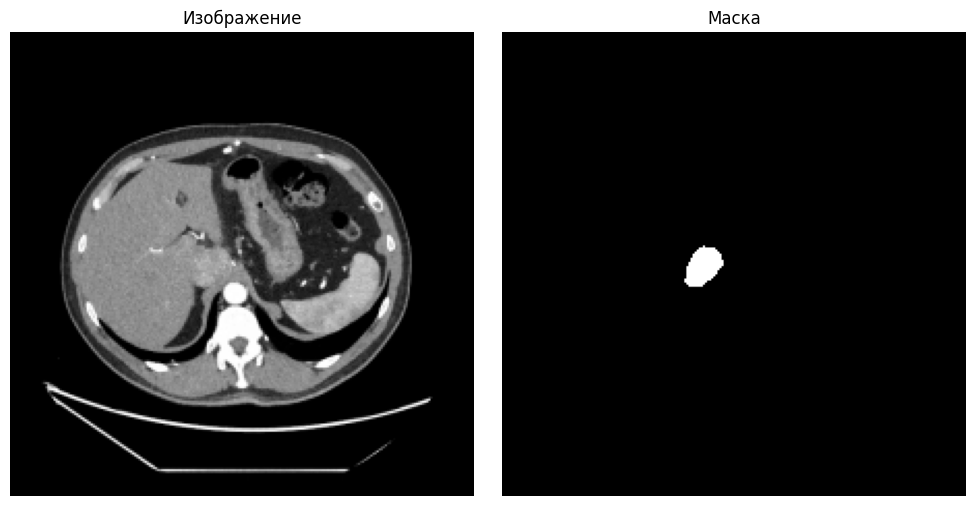

In [5]:
# проверим пару кадров в videos и masks на совпадение
# так как маски выделяют только образования, то проверяем то место, где есть сама маска - белая часть

# маска состоит из различных пикселей, поэтому что в цветовом канале меньше 127 - 0, больше - 25
masks = np.where(masks < 127, 0, 255)

# отрисуем 1 кадр с образованием и его маской
kadr = 30
img = videos[kadr]
img_seg = masks[kadr]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(img, cmap='gray', vmin=0, vmax=255)
axes[0].set_title("Изображение") 
axes[0].axis('off')

axes[1].imshow(img_seg, cmap='gray', vmin=0, vmax=255)
axes[1].set_title("Маска") 
axes[1].axis('off') 

plt.tight_layout()
plt.show()

### Новый вариант кода

In [6]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

ROOT = Path("/kaggle/working")  # рабочая папка (можно поменять)
DATASET_ROOT = Path("/kaggle/input/ct-adrenal-tumor-dataset/segmentation")  #  videos/, masks/, format.json
FORMAT_JSON = DATASET_ROOT / "format.json"

OUTPUT_BASE = ROOT / "data"  # train/val и data.yaml
PATHS_VIDEOMASKS_JSON = ROOT / "pathsVideoMasks.json"
RESERVE_VIDEOS_JSON = ROOT / "reserved_videos.json"  # 20% тест
USE_VIDEO_FRACTION = 0.8  # 80% видео для аналитики/обучения
VAL_RATIO_IN_SELECTED = 0.1  #10% валидации от выбранных кадров

IMG_SHAPE = (224, 224)
CLASS_NAME = "tumor"
CLASS_INDEX = 0

os.makedirs(ROOT, exist_ok=True)
print("CONFIG:", {"ROOT": str(ROOT), "DATASET_ROOT": str(DATASET_ROOT), "FORMAT_JSON": str(FORMAT_JSON)})

CONFIG: {'ROOT': '/kaggle/working', 'DATASET_ROOT': '/kaggle/input/ct-adrenal-tumor-dataset/segmentation', 'FORMAT_JSON': '/kaggle/input/ct-adrenal-tumor-dataset/segmentation/format.json'}


In [7]:
# Cell 2 - собрать словарь video -> [masks] и сохранить
with open(FORMAT_JSON, "r", encoding="utf-8") as f:
    format_data = json.load(f)

records = list(format_data.values()) if isinstance(format_data, dict) else list(format_data)
paths_vm = defaultdict(list)

def resolve_to_dataset_root(p_raw: str, dataset_root: Path) -> str:
    """
    Приводит путь из format.json к реальному пути в файловой системе:
    - если путь начинается с 'data/segmentation' -> заменяет этот префикс на DATASET_ROOT
    - если указанный путь существует как есть -> возвращает его
    - если не существует -> пробует dataset_root / p_raw
    - если всё ещё не найдено -> пробует Path.cwd() / p_raw
    Возвращает строку пути (необязательно resolved), сохраняет как абсолютный путь, если найден.
    """
    if p_raw is None:
        return None
    p = str(p_raw)

    # 1) специальная замена префикса 'data/segmentation' -> DATASET_ROOT
    if p.startswith("data/segmentation"):
        replaced = p.replace("data/segmentation", str(dataset_root))
        cand = Path(replaced)
        if cand.exists():
            return str(cand)

    # 2) если путь уже существует как есть
    cand = Path(p)
    if cand.exists():
        return str(cand)

    # 3) попробовать как относительный внутри DATASET_ROOT
    cand = dataset_root / cand
    if cand.exists():
        return str(cand)

    # 4) попробовать относительный к текущей рабочей директории
    cand = Path.cwd() / p
    if cand.exists():
        return str(cand)

    # 5) вернуть best-effort (DATASET_ROOT / исходное имя файла) — даже если не существует, это то что хотели
    #    тут мы пытаемся сохранить ожидаемый абсолютный путь под DATASET_ROOT
    fallback = dataset_root / Path(p).name
    return str(fallback)

for rec in records:
    vpath = rec.get("video_path")
    mpath = rec.get("mask_path")
    if vpath is None or mpath is None:
        continue

    v_res = resolve_to_dataset_root(vpath, DATASET_ROOT)
    m_res = resolve_to_dataset_root(mpath, DATASET_ROOT)

    paths_vm[v_res].append(m_res)

# Сохранение словаря
with open(PATHS_VIDEOMASKS_JSON, "w", encoding="utf-8") as fout:
    json.dump(paths_vm, fout, ensure_ascii=False, indent=2)

print(f"Собрано видео: {len(paths_vm)}. Пример (пара первых):")
for i, (k, v) in enumerate(paths_vm.items()):
    print(i+1, k, "->", len(v), "masks")
    if i >= 4: break

Собрано видео: 815. Пример (пара первых):
1 /kaggle/input/ct-adrenal-tumor-dataset/segmentation/videos/ID1_NATIVE_SE1.npy -> 2 masks
2 /kaggle/input/ct-adrenal-tumor-dataset/segmentation/videos/ID1_ARTERIAL_SE6.npy -> 2 masks
3 /kaggle/input/ct-adrenal-tumor-dataset/segmentation/videos/ID1_VENOUS_SE7.npy -> 2 masks
4 /kaggle/input/ct-adrenal-tumor-dataset/segmentation/videos/ID1_DELAY_SE3.npy -> 2 masks
5 /kaggle/input/ct-adrenal-tumor-dataset/segmentation/videos/ID2_NATIVE_SE1.npy -> 1 masks


In [8]:
# Cell 3 - разделение видео: используем 80%, оставляем 20% для независимого теста
all_videos = list(paths_vm.keys())
all_videos.sort()
n_all = len(all_videos)
n_use = int(round(USE_VIDEO_FRACTION * n_all))
random.Random(SEED).shuffle(all_videos)

selected_videos = all_videos[:n_use]
reserved_videos = all_videos[n_use:]

with open(RESERVE_VIDEOS_JSON, "w", encoding="utf-8") as f:
    json.dump({"reserved": reserved_videos, "selected": selected_videos}, f, ensure_ascii=False, indent=2)

print(f"Всего видео: {n_all}; используем: {len(selected_videos)}; резерв: {len(reserved_videos)}")
print("Первые 3 выбранных:", selected_videos[:3])
print("Первые 3 зарезервированных:", reserved_videos[:3])

Всего видео: 815; используем: 652; резерв: 163
Первые 3 выбранных: ['/kaggle/input/ct-adrenal-tumor-dataset/segmentation/videos/ID84_NATIVE.npy', '/kaggle/input/ct-adrenal-tumor-dataset/segmentation/videos/ID218_NATIVE.npy', '/kaggle/input/ct-adrenal-tumor-dataset/segmentation/videos/ID207_VENOUS.npy']
Первые 3 зарезервированных: ['/kaggle/input/ct-adrenal-tumor-dataset/segmentation/videos/ID202_DELAY.npy', '/kaggle/input/ct-adrenal-tumor-dataset/segmentation/videos/ID86_NATIVE.npy', '/kaggle/input/ct-adrenal-tumor-dataset/segmentation/videos/ID9_NATIVE_SE1.npy']


In [9]:
# Cell 4 - пройти видео по одному, без загрузки всего в память
positive_frames = []  # (video_path, frame_index)
negative_frames = []  # (video_path, frame_index)
video_frame_counts = {}  # для отладки: сколько кадров в видео

def ensure_bin_mask(arr):
    """Привести маску к бинарной 0/255"""
    # arr shape (T,H,W)
    if arr.dtype != np.uint8:
        arr = arr.astype(np.uint8)
    # считаем >127 как белое
    bin_arr = np.where(arr > 127, 255, 0).astype(np.uint8)
    return bin_arr

for vp in selected_videos:
    vp_path = Path(vp)
    if not vp_path.exists():
        # попробуем DATASET_ROOT / vp
        testp = Path.cwd() / vp
        if testp.exists():
            vp_path = testp
        else:
            alt = DATASET_ROOT / vp_path.name
            if alt.exists():
                vp_path = alt
            else:
                print("WARNING: видео не найдено:", vp)
                continue

    # Загружаем видео (shape (T,H,W))
    video = np.load(vp_path)
    T = video.shape[0]
    video_frame_counts[vp] = T

    # Загружаем все маски, связанные с этим видео (каждая маска shape (T,H,W))
    mask_paths = paths_vm[vp]
    masks_list = []
    for mp in mask_paths:
        mp_path = Path(mp)
        if not mp_path.exists():
            mp_try = Path.cwd() / mp
            if mp_try.exists():
                mp_path = mp_try
            else:
                alt = DATASET_ROOT / mp_path.name
                if alt.exists():
                    mp_path = alt
                else:
                    print("WARNING: маска не найдена:", mp)
                    continue
        m = np.load(mp_path)
        masks_list.append(ensure_bin_mask(m))

    if len(masks_list) == 0:
        # нет масок вообще для этого видео -> все кадры негативные
        for t in range(T):
            negative_frames.append((vp, t))
        continue

    # Объединяем логически кадр по кадру (OR) при проверке наличия пикселей:
    # Не создаём гигантский массив, обрабатываем кадры по одному
    for t in range(T):
        # проверяем, есть ли ненулевые пиксели в любом mask[:,t,:,:]
        has = False
        for m in masks_list:
            if np.any(m[t] != 0):
                has = True
                break
        if has:
            positive_frames.append((vp, t))
        else:
            negative_frames.append((vp, t))

print("Итого кадров (positive, negative):", len(positive_frames), len(negative_frames))
# суммарное число кадров видео из датасета (из всех видео) для которых хотя бы на одной маске есть выделенный пиксель:
total_positive = len(positive_frames)
print("Суммарное количество кадров с выделениями:", total_positive)

Итого кадров (positive, negative): 7191 27365
Суммарное количество кадров с выделениями: 7191


In [10]:
if total_positive == 0:
    raise RuntimeError("Ни одного положительного кадра не найдено — проверьте маски!")

if len(negative_frames) < total_positive:
    print("WARNING: недостаточно негативных кадров, используем все и продублируем (редко).")
    # на всякий случай — репит негативов (лучше собрать больше данных)
    multiplier = int(np.ceil(total_positive / max(1, len(negative_frames))))
    negative_frames_expanded = negative_frames * multiplier
    negative_selected = negative_frames_expanded[:total_positive]
else:
    negative_selected = random.Random(SEED).sample(negative_frames, total_positive)

print("Выбрано негативных кадров:", len(negative_selected), "для баланса с позитивными:", total_positive)

# объединяем и перемешиваем
combined = [(vp, t, 1) for vp, t in positive_frames] + [(vp, t, 0) for vp, t in negative_selected]
random.Random(SEED).shuffle(combined)
print("Итого примеров (после балансировки):", len(combined))

Выбрано негативных кадров: 7191 для баланса с позитивными: 7191
Итого примеров (после балансировки): 14382


In [11]:
train_examples, val_examples = train_test_split(combined, test_size=VAL_RATIO_IN_SELECTED, random_state=SEED, shuffle=True)

print("Train examples:", len(train_examples), "Val examples:", len(val_examples))

# Подготовка директорий
def prepare_dirs(base_out):
    img_dir = base_out / "images"
    lbl_dir = base_out / "labels"
    if base_out.exists():
        # не удаляем полностью (можно раскомментировать удаление при желании)
        pass
    img_dir.mkdir(parents=True, exist_ok=True)
    lbl_dir.mkdir(parents=True, exist_ok=True)
    return img_dir, lbl_dir

train_img_dir, train_lbl_dir = prepare_dirs(OUTPUT_BASE / "train")
val_img_dir, val_lbl_dir = prepare_dirs(OUTPUT_BASE / "val")

# Счетчик для уникальных имён файлов
global_counter = 0

def save_example(vp, t, positive, out_img_dir, out_lbl_dir, counter):
    """Сохраняет кадр t из видео vp как counter.png и соответствующий .txt.
       Для положительного кадра строит контуры по объединённой маске (все маски OR).
    """
    # загружаем видео и все маски для данного видео (можно кешировать, но для простоты читаем)
    vp_path = Path(vp)
    if not vp_path.exists():
        vp_path = Path.cwd() / vp_path
    video = np.load(vp_path)  # (T,H,W)
    frame = video[t].astype(np.uint8)
    # сохраняем изображение как BGR
    fn = f"{counter:06d}.png"
    bgr = cv2.cvtColor(frame, cv2.COLOR_GRAY2BGR)
    cv2.imwrite(str(out_img_dir / fn), bgr)

    # собираем объединённую маску для этого кадра
    masks = []
    for mp in paths_vm[vp]:
        mp_path = Path(mp)
        if not mp_path.exists():
            mp_path = Path.cwd() / mp_path
        if mp_path.exists():
            m = np.load(mp_path)
            masks.append(ensure_bin_mask(m)[t])
    if len(masks) == 0:
        combined_mask = np.zeros(IMG_SHAPE, dtype=np.uint8)
    else:
        # OR всех масок
        combined_mask = np.zeros_like(masks[0])
        for mm in masks:
            combined_mask = np.logical_or(combined_mask, mm).astype(np.uint8) * 255

    # теперь ищем контуры и создаём .txt (инстанс-полигоны)
    txt_path = out_lbl_dir / fn.replace(".png", ".txt")
    lines = []
    if positive:
        # найдем контуры (в OpenCV нужно бинарное изображение uint8)
        ms = combined_mask.copy()
        if ms.max() > 1:
            ms = (ms > 127).astype(np.uint8) * 255
        contours, _ = cv2.findContours(ms, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        H, W = ms.shape
        for cnt in contours:
            if cnt is None:
                continue
            cnt = cnt.squeeze()
            if cnt.ndim != 2 or cnt.shape[0] < 3:
                continue
            # Полигон точек (x,y) flatten
            poly = cnt.flatten().tolist()
            # Нормализация
            norm = []
            for idx_c, coord in enumerate(poly):
                if idx_c % 2 == 0:  # x
                    norm.append(coord / W)
                else:               # y
                    norm.append(coord / H)
            # YOLOv8-seg: class-index + polygon coords
            lines.append(str(CLASS_INDEX) + " " + " ".join(f"{v:.6f}" for v in norm))
        # если не нашлось контуров (редкость) — записываем пустой файл
    # Сохраняем txt (может быть пустой)
    with open(txt_path, "w", encoding="utf-8") as f:
        f.write("\n".join(lines))

    return fn

# Сохраняем train
print("Экспорт train...")
for ex in train_examples:
    vp, t, pos = ex
    fn = save_example(vp, t, pos, train_img_dir, train_lbl_dir, global_counter)
    global_counter += 1
    if global_counter % 500 == 0:
        print("Сохранено примеров:", global_counter)

# Сохраняем val
print("Экспорт val...")
for ex in val_examples:
    vp, t, pos = ex
    fn = save_example(vp, t, pos, val_img_dir, val_lbl_dir, global_counter)
    global_counter += 1

print("Готово. Всего сохранено файлов:", global_counter)

Train examples: 12943 Val examples: 1439
Экспорт train...
Сохранено примеров: 500
Сохранено примеров: 1000
Сохранено примеров: 1500
Сохранено примеров: 2000
Сохранено примеров: 2500
Сохранено примеров: 3000
Сохранено примеров: 3500
Сохранено примеров: 4000
Сохранено примеров: 4500
Сохранено примеров: 5000
Сохранено примеров: 5500
Сохранено примеров: 6000
Сохранено примеров: 6500
Сохранено примеров: 7000
Сохранено примеров: 7500
Сохранено примеров: 8000
Сохранено примеров: 8500
Сохранено примеров: 9000
Сохранено примеров: 9500
Сохранено примеров: 10000
Сохранено примеров: 10500
Сохранено примеров: 11000
Сохранено примеров: 11500
Сохранено примеров: 12000
Сохранено примеров: 12500
Экспорт val...
Готово. Всего сохранено файлов: 14382


In [12]:
import yaml

yaml_config = {
    'path': str(OUTPUT_BASE),  # относительный путь к data
    'train': 'train/images',
    'val': 'val/images',
    'names': {CLASS_INDEX: CLASS_NAME}
}

with open(OUTPUT_BASE / "data.yaml", "w", encoding="utf-8") as f:
    yaml.dump(yaml_config, f, sort_keys=False, allow_unicode=True)

print("data.yaml сохранён по пути:", OUTPUT_BASE / "data.yaml")
print("Краткий отчёт:")
print("  Положительных кадров (с сегментацией) использовано:", total_positive)
print("  Негативных (баланс) использовано:", len(negative_selected))
print("  Итого сохранённых кадров:", len(combined))
print("  Train:", len(train_examples), " Val:", len(val_examples))
print("  Папки с изображениями (пример):", train_img_dir, val_img_dir)
print("  Словарь pathsVideoMasks сохранён:", PATHS_VIDEOMASKS_JSON)
print("  Резервные видео (20%) сохранены:", RESERVE_VIDEOS_JSON)

data.yaml сохранён по пути: /kaggle/working/data/data.yaml
Краткий отчёт:
  Положительных кадров (с сегментацией) использовано: 7191
  Негативных (баланс) использовано: 7191
  Итого сохранённых кадров: 14382
  Train: 12943  Val: 1439
  Папки с изображениями (пример): /kaggle/working/data/train/images /kaggle/working/data/val/images
  Словарь pathsVideoMasks сохранён: /kaggle/working/pathsVideoMasks.json
  Резервные видео (20%) сохранены: /kaggle/working/reserved_videos.json


In [13]:
!ls /kaggle/working

data  __notebook__.ipynb  pathsVideoMasks.json	reserved_videos.json


# Данные для обучения по фото готовы, можно переходить к модели

# Теперь перейдем к работе с моделью YOLO

In [14]:
!python -m pip install -U ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 17.1 MB/s eta 0:00:00


In [15]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [16]:
# model_nano = YOLO("yolo11n-seg.pt")
model_small = YOLO("yolo11s-seg.pt")
# model_medium = YOLO("yolo11m-seg.pt")
# model_large = YOLO("yolo11l-seg.pt")
# model_extra = YOLO("yolo11x-seg.pt")

In [17]:
model = model_small

In [18]:
# results = model.train(
#     task='segment',
#     data="/kaggle/working/data/data.yaml",
#     epochs=250,
#     imgsz=224,
#     batch=128,

#     # контроль
#     save=True,
#     save_period=5,        # чекпоинт каждую 5 эпоху
#     patience=50,       # ранняя остановка

#     # мониторинг
#     plots=True,           # обязательно
#     verbose=True,
#     show=False,           # НЕ показывать окна

#     # инфраструктура
#     project='/kaggle/working/results',
#     name='exp1',
#     exist_ok=True,
    
#     workers=0,
# )

In [19]:
# # Сохраняем модель 
# import datetime

# today = datetime.datetime.today().strftime('%Y-%m-%d')

# model_filename = f"yolo_model_{today}.pt"
# model_path = os.path.join("/kaggle/working/results/exp1/weights/best.pt", model_filename)
# model.save("/kaggle/working/results/exp1/weights/best.pt")

# os.listdir('/kaggle/working/')

In [20]:
# model.save("/kaggle/working/results/exp1/weights/best.pt")

In [21]:
# csv_path = '/kaggle/working/results/train2/results.csv'

# # Проверяем, что файл существует
# if not os.path.exists(csv_path):
#     raise FileNotFoundError(f"CSV файл с логами не найден по пути: {csv_path}")

# # Загружаем данные из CSV
# df = pd.read_csv(csv_path)
# print("Столбцы CSV:", df.columns)
# print(df.head())

In [22]:
# print(len(images_saved))

In [23]:
# import math

# df = df.drop(columns=['lr/pg1', 'lr/pg2'])

# train_metrics = [col for col in df.columns if col.startswith('train/')]
# val_metrics = [col.replace('train/', 'val/') for col in train_metrics if col.replace('train/', 'val/') in df.columns]
# metric_metrics = [col for col in df.columns if col.startswith('metrics/')]

# n_cols = 3
# n_rows = math.ceil(len(train_metrics) / n_cols) + math.ceil(len(metric_metrics) / n_cols)

# fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
# axes = axes.flatten()

# for i, train_metric in enumerate(train_metrics):
#     val_metric = train_metric.replace('train/', 'val/')
    
#     axes[i].plot(df['epoch'], df[train_metric], linestyle='-', label=f'{train_metric}', color='blue')
#     axes[i].plot(df['epoch'], df[val_metric], linestyle='--', label=f'{val_metric}', color='red')
    
#     axes[i].set_xlabel('Epoch')
#     axes[i].set_ylabel(train_metric.split('/')[-1])
#     axes[i].set_title(f'{train_metric.split("/")[-1]} over epochs')
#     axes[i].legend()
#     axes[i].grid(True)

# # Рисуем метрики metrics/
# for j, metric in enumerate(metric_metrics, start=len(train_metrics)):
#     axes[j].plot(df['epoch'], df[metric], linestyle='-', label=metric, color='green')
    
#     axes[j].set_xlabel('Epoch')
#     axes[j].set_ylabel(metric.split('/')[-1])
#     axes[j].set_title(f'{metric.split("/")[-1]} over epochs')
#     axes[j].legend()
#     axes[j].grid(True)

# # Удаление лишних подграфиков
# for i in range(len(train_metrics) + len(metric_metrics), len(axes)):
#     fig.delaxes(axes[i])

# plt.tight_layout()
# plt.savefig(f"grafics_{today}.png", dpi=300) 
# plt.show()

In [24]:
# import random

# # Выбираем 5 случайных индексов из images_saved
# random_indices = random.sample(range(len(images_saved)), 5)

# # Создаем фигуру для графиков (3 строки, 5 столбцов)
# fig, axes = plt.subplots(3, 5, figsize=(15, 10))

# for col, kadr in enumerate(random_indices):
#     # Загружаем изображения
#     img = images_saved[kadr]
#     img_seg = masks_saved_images[kadr]

#     # Преобразуем в BGR → RGB
#     img_pred = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

#     # Получаем предсказание YOLO
#     prediction = model.predict(img_pred)

#     # Конвертируем результат YOLO в NumPy
#     predicted_img = prediction[0].plot()

#     # Заполняем текущий столбец из 3 изображений
#     axes[0, col].imshow(img, cmap='gray', vmin=0, vmax=255)
#     axes[0, col].set_title(f"sourse_image (#{kadr})")
#     axes[0, col].axis('off')

#     axes[1, col].imshow(img_seg, cmap='gray', vmin=0, vmax=255)
#     axes[1, col].set_title("mask (tumor)")
#     axes[1, col].axis('off')

#     axes[2, col].imshow(predicted_img)
#     axes[2, col].set_title("YOLO prediction")
#     axes[2, col].axis('off')

# plt.tight_layout()
# plt.savefig(f"examples_{today}.png", dpi=300)
# plt.show()

In [25]:
# img = images_saved[63]
# img_pred = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
# prediction = model.predict(img_pred)
# print(prediction[0].boxes)

# Проверка модели на видео (прогоню каждый кард через модель, выгружу npy и mp4)

In [26]:
# model = os.path.join(project_dir, 'yolo_seg_small_040325.pt')
# model = YOLO(model)

In [27]:
# # цикл пикл
# import cv2
# import numpy as np
# from pathlib import Path

# def process_and_save_video_all(video_array: np.ndarray,
#                                model,
#                                output_original: str,
#                                output_detection: str,
#                                output_segmentation: str,
#                                conf_threshold: float = 0.5,
#                                mask_threshold: float = 0.5,
#                                fps: int = 10,
#                                detection_color: tuple = (0, 255, 0),
#                                mask_color: tuple = (255, 255, 255)):
#     """
#     Обрабатывает видео и сохраняет три файла:
#       1) оригинальное видео,
#       2) видео с детекцией bbox,
#       3) видео с бинарными масками сегментации.

#     :param video_array: np.ndarray формы (N, H, W) или (N, H, W, 3)
#     :param model: YOLOv11_seg-модель (Ultralytics), поддерживает task="segment"
#     :param output_original: путь для сохранения оригинального видео (.mp4)
#     :param output_detection: путь для видео с детекцией bbox
#     :param output_segmentation: путь для видео с сегментацией (чёрно-белые кадры)
#     :param conf_threshold: минимальный confidence для боксов
#     :param mask_threshold: порог бинаризации вероятностных масок
#     :param fps: кадры в секунду
#     :param detection_color: цвет bbox (B, G, R)
#     :param mask_color: цвет объекта в маске (по умолчанию белый)
#     """
#     N, H, W = video_array.shape[0], video_array.shape[1], video_array.shape[2]

#     # Подготовка трёх VideoWriter’ов
#     def make_writer(path):
#         p = Path(path)
#         p.parent.mkdir(parents=True, exist_ok=True)
#         fourcc = cv2.VideoWriter_fourcc(*'mp4v')
#         return cv2.VideoWriter(str(p), fourcc, fps, (W, H))
    
#     writer_orig = make_writer(output_original)
#     writer_det  = make_writer(output_detection)
#     writer_seg  = make_writer(output_segmentation)

#     for i in range(N):
#         frame = video_array[i]
#         # приводим к BGR uint8
#         if frame.ndim == 2:
#             frame_bgr = cv2.cvtColor(frame, cv2.COLOR_GRAY2BGR)
#         else:
#             frame_bgr = frame.astype(np.uint8)

#         # 1) сохраняем оригинал
#         writer_orig.write(frame_bgr)

#         # 2) предсказание (детекция + сегментация)
#         results = model(frame_bgr, conf=conf_threshold, task="segment", verbose=False)[0]

#         # --- видео с детекцией bbox ---
#         det_frame = frame_bgr.copy()
#         for box in results.boxes.data.cpu().numpy():
#             x1, y1, x2, y2, conf, cls = box
#             if conf < conf_threshold:
#                 continue
#             pt1 = (int(x1), int(y1))
#             pt2 = (int(x2), int(y2))
#             cv2.rectangle(det_frame, pt1, pt2, detection_color, 2)
#             label = f"{results.names[int(cls)]} {conf:.2f}"
#             cv2.putText(det_frame, label, (pt1[0], pt1[1] - 5),
#                         cv2.FONT_HERSHEY_SIMPLEX, 0.5, detection_color, 2)
#         writer_det.write(det_frame)

#         # --- видео с сегментацией (бинарные маски) ---
#         mask_output = np.zeros((H, W), dtype=np.uint8)
#         if results.masks is not None and results.masks.data.numel() > 0:
#             masks = results.masks.data.cpu().numpy()  # shape: (M, H, W)
#             for mask in masks:
#                 binary = (mask > mask_threshold).astype(np.uint8) * mask_color[0]  # маска белая
#                 mask_output = np.maximum(mask_output, binary)
#         mask_bgr = cv2.cvtColor(mask_output, cv2.COLOR_GRAY2BGR)
#         writer_seg.write(mask_bgr)

#     # закрываем все
#     writer_orig.release()
#     writer_det.release()
#     writer_seg.release()

#     print("Сохранены:")
#     print(f"   • Оригинал:   {output_original}")
#     print(f"   • Детекция:   {output_detection}")
#     print(f"   • Сегментации:{output_segmentation}")

In [28]:
# # Пример вызова:
# num_video = 4

# output_path=f'/kaggle/working/final_videos/'

# process_and_save_video_all(
#     video_array=videos_saved[num_video],
#     model=model,
#     output_original = output_path + f"video{num_video}.mp4",
#     output_detection = output_path + f"video{num_video}_det.mp4",
#     output_segmentation = output_path + f"video{num_video}_seg.mp4",
#     conf_threshold=0.5,
#     mask_threshold=0.5,
#     fps=15
# )